In [1]:
# DAY 26 - HYPERPARAMETER TUNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Prepare features and target

feature_columns = [
    "sales",
    "quantity",
    "discount",
    "shipping_cost",
    "shipping_days"
]

X = df[feature_columns].astype(float)

# Target: 1 = positive profit, 0 = zero/negative profit
y = (df["profit"] > 0).astype(int)

print("Features prepared successfully!")

print("\nFeatures:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features prepared successfully!

Features:
['sales', 'quantity', 'discount', 'shipping_cost', 'shipping_days']

X shape: (51290, 5)
y shape: (51290,)

Target distribution:
profit
1    38079
0    13211
Name: count, dtype: int64


In [4]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Train-test split completed!
Training data: (41032, 5)
Testing data: (10258, 5)


In [5]:
# Train the untuned Random Forest model

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Random Forest Accuracy:",
      round(baseline_accuracy, 3))

Baseline Random Forest Accuracy: 0.913


In [6]:
# Define hyperparameter combinations for Random Forest

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Hyperparameter grid created successfully!")

for parameter, values in param_grid.items():
    print(parameter, ":", values)

Hyperparameter grid created successfully!
n_estimators : [50, 100, 200]
max_depth : [None, 10, 20]
min_samples_split : [2, 5]
min_samples_leaf : [1, 2]


In [7]:
# Perform GridSearchCV for hyperparameter tuning

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting GridSearchCV...")

grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully!")

Starting GridSearchCV...
GridSearchCV completed successfully!


In [8]:
# Display the best hyperparameters found by GridSearchCV

print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 3))

Best Hyperparameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.92


In [9]:
# Get the best tuned Random Forest model

tuned_model = grid_search.best_estimator_

print("Tuned Random Forest model created successfully!")

print("\nBest Parameters:")
print(tuned_model.get_params())

Tuned Random Forest model created successfully!

Best Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [10]:
# Evaluate the tuned Random Forest on the test data

tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

print("Tuned Random Forest Accuracy:",
      round(tuned_accuracy, 3))

Tuned Random Forest Accuracy: 0.92


In [11]:
# Compare baseline and tuned Random Forest performance

performance_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Untuned",
        "Random Forest - Tuned"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ]
})

performance_comparison["Test Accuracy"] = (
    performance_comparison["Test Accuracy"].round(3)
)

print(performance_comparison)

                     Model  Test Accuracy
0  Random Forest - Untuned          0.913
1    Random Forest - Tuned          0.920


In [12]:
# Calculate the change in performance after tuning

accuracy_change = tuned_accuracy - baseline_accuracy

print("Baseline Accuracy:",
      round(baseline_accuracy, 3))

print("Tuned Accuracy:",
      round(tuned_accuracy, 3))

print("Accuracy Change:",
      round(accuracy_change, 3))

Baseline Accuracy: 0.913
Tuned Accuracy: 0.92
Accuracy Change: 0.007


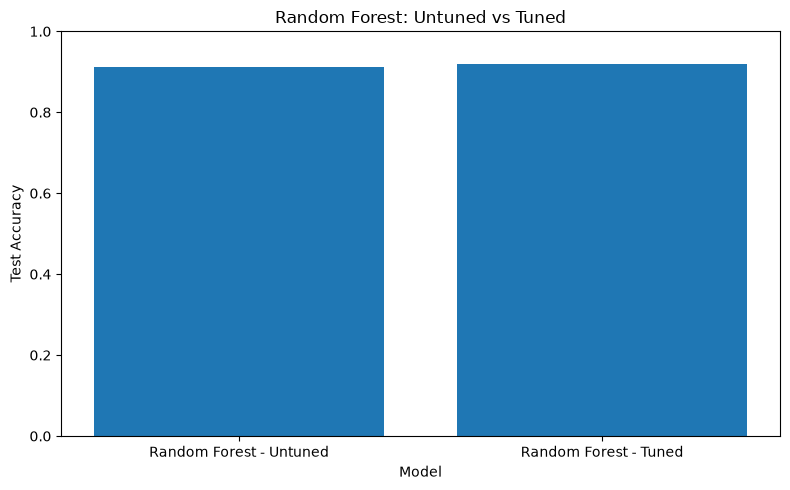

In [13]:
# Visualize untuned vs tuned Random Forest performance

plt.figure(figsize=(8, 5))

plt.bar(
    performance_comparison["Model"],
    performance_comparison["Test Accuracy"]
)

plt.title("Random Forest: Untuned vs Tuned")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.show()

In [14]:
# Save the hyperparameter tuning performance comparison

performance_comparison.to_csv(
    "hyperparameter_tuning_comparison.csv",
    index=False
)

print("Performance comparison saved successfully!")
print("File: hyperparameter_tuning_comparison.csv")

Performance comparison saved successfully!
File: hyperparameter_tuning_comparison.csv


In [15]:
# Save the hyperparameter tuning performance comparison

performance_comparison.to_csv(
    "hyperparameter_tuning_comparison.csv",
    index=False
)

print("Performance comparison saved successfully!")
print("File: hyperparameter_tuning_comparison.csv")

Performance comparison saved successfully!
File: hyperparameter_tuning_comparison.csv


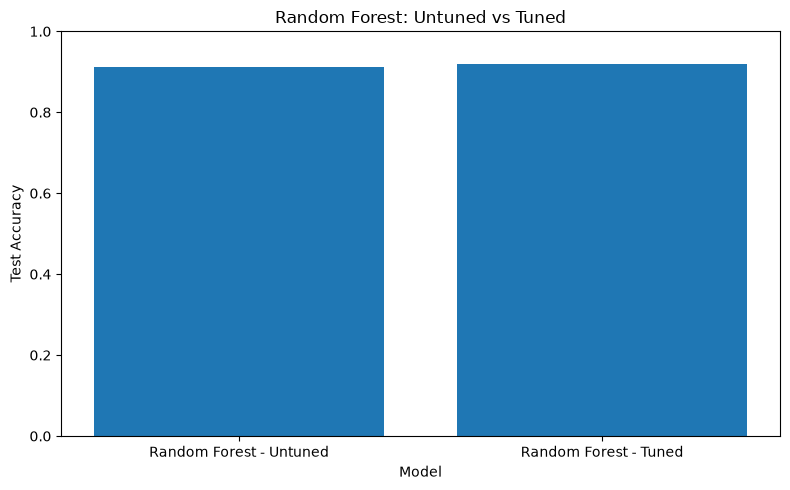

Comparison graph saved successfully!
File: hyperparameter_tuning_comparison.png


In [16]:
# Save the untuned vs tuned performance graph

plt.figure(figsize=(8, 5))

plt.bar(
    performance_comparison["Model"],
    performance_comparison["Test Accuracy"]
)

plt.title("Random Forest: Untuned vs Tuned")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "hyperparameter_tuning_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison graph saved successfully!")
print("File: hyperparameter_tuning_comparison.png")

In [17]:
# Save the best hyperparameters found by GridSearchCV

best_parameters = pd.DataFrame(
    list(grid_search.best_params_.items()),
    columns=["Hyperparameter", "Best Value"]
)

best_parameters.to_csv(
    "best_parameters.csv",
    index=False
)

print("Best parameter report saved successfully!")
print("File: best_parameters.csv")

print("\nBest Parameters:")
print(best_parameters)

Best parameter report saved successfully!
File: best_parameters.csv

Best Parameters:
      Hyperparameter  Best Value
0          max_depth          10
1   min_samples_leaf           2
2  min_samples_split           2
3       n_estimators         100


In [18]:
# Final Day 26 optimization summary

print("==============================================")
print(" DAY 26 - HYPERPARAMETER TUNING SUMMARY")
print("==============================================")

print("\nBaseline Random Forest Accuracy:",
      round(baseline_accuracy, 3))

print("Tuned Random Forest Accuracy:",
      round(tuned_accuracy, 3))

print("Accuracy Change:",
      round(accuracy_change, 3))

print("\nBest Hyperparameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation Accuracy:",
      round(grid_search.best_score_, 3))

print("\n==============================================")
print(" Hyperparameter tuning completed!")
print("==============================================")

 DAY 26 - HYPERPARAMETER TUNING SUMMARY

Baseline Random Forest Accuracy: 0.913
Tuned Random Forest Accuracy: 0.92
Accuracy Change: 0.007

Best Hyperparameters:
max_depth: 10
min_samples_leaf: 2
min_samples_split: 2
n_estimators: 100

Best Cross-Validation Accuracy: 0.92

 Hyperparameter tuning completed!


In [19]:
# Final Day 26 file check

import os

files = [
    "best_parameters.csv",
    "hyperparameter_tuning_comparison.csv",
    "hyperparameter_tuning_comparison.png"
]

print("Day 26 files:")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

Day 26 files:
✅ best_parameters.csv
✅ hyperparameter_tuning_comparison.csv
✅ hyperparameter_tuning_comparison.png
